<a href="https://colab.research.google.com/github/Ishita95-harvad/AI-Solution-Summary-of-Featured-Competitions/blob/main/AI_Solution_Summary_of_Featured_Competitions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Solution Summary of Featured Competitions**
Top Kaggle Competition Solutions Summarized by Gemini-2.0-Flash

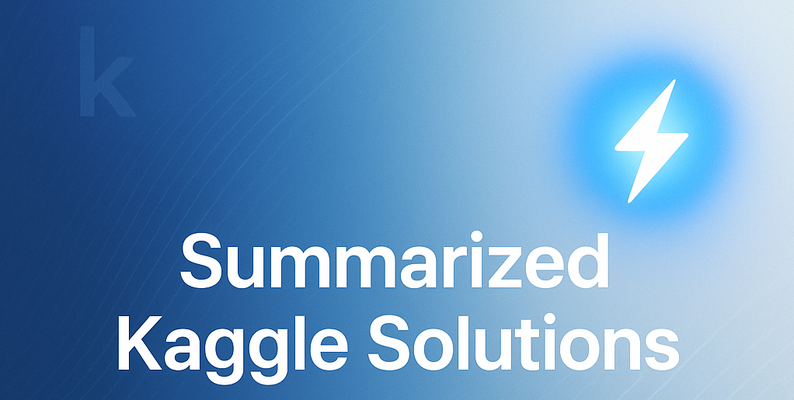

## Data loading

### Subtask:
Load the Kaggle competition solutions dataset.


**Reasoning**:
I need to load the Kaggle competition solutions dataset into a pandas DataFrame.



In [1]:
import pandas as pd

try:
    df = pd.read_csv('kaggle_competition_solutions_ai_summary.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'kaggle_competition_solutions_ai_summary.csv' not found.")
    df = None
except pd.errors.ParserError:
    print("Error: Unable to parse the CSV file. Please check the file format.")
    df = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

,Id,Slug,Title,Subtitle,ForumId,EnabledDate,DeadlineDate,Rules,DatasetDescription,AI_Summary
0,91497,march-machine-learning-mania-2025,March Machine Learning Mania 2025,Forecast the 2025 NCAA Basketball Tournaments,6794790.0,2025-02-10 18:33:44,04/08/2025 16:00:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\n<p>Each season there ...,Data Handling:\n- Used competition data only.\...
1,86411,lux-ai-season-3,NeurIPS 2024 - Lux AI Season 3,Deep space exploration!,6054504.0,2024-12-09 19:47:51,03/24/2025 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nThis is the folder fo...,Data Handling:\n- Used replays from top teams ...
2,83035,llms-you-cant-please-them-all,LLMs - You Can't Please Them All,Are LLM-judges robust to adversarial inputs?,5580705.0,2024-12-03 21:42:53,03/04/2025 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nThe competition datas...,Data Handling:\n- Used wordlists (Brown Corpus...
3,88046,santa-2024,Santa 2024 - The Perplexity Permutation Puzzle,Help Rudolph descramble holiday-related words ...,6256227.0,2024-11-21 18:56:41,01/31/2025 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nYour task in this com...,Data Handling:\n- Sorting the text alphabetica...
4,86524,fide-google-efficiency-chess-ai-challenge,FIDE & Google Efficient Chess AI Challenge,Create agents to play chess with resource cons...,6063821.0,2024-11-18 23:11:52,03/06/2025 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nCode and configuratio...,Data Handling:\n- Positions encountered during...


## Data exploration

### Subtask:
Explore the loaded dataset to understand its characteristics.


**Reasoning**:
I need to explore the dataset's characteristics, including data types, missing values, descriptive statistics, and unique values for categorical columns. I will also analyze the distribution of key variables like 'AI_Summary', 'EnabledDate', and 'DeadlineDate'.



In [2]:
# Data Shape
print(f"Data Shape: {df.shape}")

# Data Types
print("\nData Types:")
print(df.dtypes)

# Missing Values
print("\nMissing Values:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print(pd.concat([missing_values, missing_percentage], axis=1, keys=['Count', '%']))

# Descriptive Statistics for Numerical Columns
print("\nDescriptive Statistics for Numerical Columns:")
numerical_cols = df.select_dtypes(include=['number'])
print(numerical_cols.describe())

# Unique Values for Categorical Columns
print("\nUnique Values for Categorical Columns:")
categorical_cols = df.select_dtypes(exclude=['number'])
for col in categorical_cols.columns:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Examples: {df[col].unique()[:5]}")

# Distribution of Key Variables
print("\nDistribution of AI_Summary:")
print(df['AI_Summary'].value_counts().head(10))

print("\nDistribution of EnabledDate and DeadlineDate:")
print(df[['EnabledDate', 'DeadlineDate']].describe())

Data Shape: (128, 10)

Data Types:
Id                      int64
Slug                   object
Title                  object
Subtitle               object
ForumId               float64
EnabledDate            object
DeadlineDate           object
Rules                  object
DatasetDescription     object
AI_Summary             object
dtype: object

Missing Values:
                    Count      %
Id                      0  0.000
Slug                    0  0.000
Title                   0  0.000
Subtitle                0  0.000
ForumId                 0  0.000
EnabledDate             0  0.000
DeadlineDate            0  0.000
Rules                   0  0.000
DatasetDescription      0  0.000
AI_Summary              4  3.125

Descriptive Statistics for Numerical Columns:
                Id       ForumId
count    128.00000  1.280000e+02
mean   37001.21875  2.123996e+06
std    22585.07180  1.738359e+06
min     6818.00000  6.113600e+04
25%    18600.75000  5.740168e+05
50%    31916.00000  1.7184

## Data cleaning

### Subtask:
Clean the dataset by handling missing values in the 'AI_Summary' column and converting the date columns to datetime objects.


**Reasoning**:
Handle missing values in the 'AI_Summary' column by filling them with "Unknown", convert 'EnabledDate' and 'DeadlineDate' to datetime objects, and then verify the changes.



In [3]:
# Fill missing 'AI_Summary' values with "Unknown"
df['AI_Summary'].fillna("Unknown", inplace=True)

# Convert date columns to datetime objects
for col in ['EnabledDate', 'DeadlineDate']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Verify changes
print(df.isnull().sum())
print(df.dtypes)
display(df.head())

Id                    0
Slug                  0
Title                 0
Subtitle              0
ForumId               0
EnabledDate           0
DeadlineDate          0
Rules                 0
DatasetDescription    0
AI_Summary            0
dtype: int64
Id                             int64
Slug                          object
Title                         object
Subtitle                      object
ForumId                      float64
EnabledDate           datetime64[ns]
DeadlineDate          datetime64[ns]
Rules                         object
DatasetDescription            object
AI_Summary                    object
dtype: object


<ipython-input-3-af2d501fade3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AI_Summary'].fillna("Unknown", inplace=True)


,Id,Slug,Title,Subtitle,ForumId,EnabledDate,DeadlineDate,Rules,DatasetDescription,AI_Summary
0,91497,march-machine-learning-mania-2025,March Machine Learning Mania 2025,Forecast the 2025 NCAA Basketball Tournaments,6794790.0,2025-02-10 18:33:44,2025-04-08 16:00:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\n<p>Each season there ...,Data Handling:\n- Used competition data only.\...
1,86411,lux-ai-season-3,NeurIPS 2024 - Lux AI Season 3,Deep space exploration!,6054504.0,2024-12-09 19:47:51,2025-03-24 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nThis is the folder fo...,Data Handling:\n- Used replays from top teams ...
2,83035,llms-you-cant-please-them-all,LLMs - You Can't Please Them All,Are LLM-judges robust to adversarial inputs?,5580705.0,2024-12-03 21:42:53,2025-03-04 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nThe competition datas...,Data Handling:\n- Used wordlists (Brown Corpus...
3,88046,santa-2024,Santa 2024 - The Perplexity Permutation Puzzle,Help Rudolph descramble holiday-related words ...,6256227.0,2024-11-21 18:56:41,2025-01-31 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nYour task in this com...,Data Handling:\n- Sorting the text alphabetica...
4,86524,fide-google-efficiency-chess-ai-challenge,FIDE & Google Efficient Chess AI Challenge,Create agents to play chess with resource cons...,6063821.0,2024-11-18 23:11:52,2025-03-06 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nCode and configuratio...,Data Handling:\n- Positions encountered during...


**Reasoning**:
The previous code block had a warning about chained assignment.  I will fix it and re-run the code to ensure the changes are correctly applied.



In [4]:
# Fill missing 'AI_Summary' values with "Unknown"
df['AI_Summary'] = df['AI_Summary'].fillna("Unknown")

# Convert date columns to datetime objects
for col in ['EnabledDate', 'DeadlineDate']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Verify changes
print(df.isnull().sum())
print(df.dtypes)
display(df.head())

Id                    0
Slug                  0
Title                 0
Subtitle              0
ForumId               0
EnabledDate           0
DeadlineDate          0
Rules                 0
DatasetDescription    0
AI_Summary            0
dtype: int64
Id                             int64
Slug                          object
Title                         object
Subtitle                      object
ForumId                      float64
EnabledDate           datetime64[ns]
DeadlineDate          datetime64[ns]
Rules                         object
DatasetDescription            object
AI_Summary                    object
dtype: object


,Id,Slug,Title,Subtitle,ForumId,EnabledDate,DeadlineDate,Rules,DatasetDescription,AI_Summary
0,91497,march-machine-learning-mania-2025,March Machine Learning Mania 2025,Forecast the 2025 NCAA Basketball Tournaments,6794790.0,2025-02-10 18:33:44,2025-04-08 16:00:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\n<p>Each season there ...,Data Handling:\n- Used competition data only.\...
1,86411,lux-ai-season-3,NeurIPS 2024 - Lux AI Season 3,Deep space exploration!,6054504.0,2024-12-09 19:47:51,2025-03-24 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nThis is the folder fo...,Data Handling:\n- Used replays from top teams ...
2,83035,llms-you-cant-please-them-all,LLMs - You Can't Please Them All,Are LLM-judges robust to adversarial inputs?,5580705.0,2024-12-03 21:42:53,2025-03-04 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nThe competition datas...,Data Handling:\n- Used wordlists (Brown Corpus...
3,88046,santa-2024,Santa 2024 - The Perplexity Permutation Puzzle,Help Rudolph descramble holiday-related words ...,6256227.0,2024-11-21 18:56:41,2025-01-31 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nYour task in this com...,Data Handling:\n- Sorting the text alphabetica...
4,86524,fide-google-efficiency-chess-ai-challenge,FIDE & Google Efficient Chess AI Challenge,Create agents to play chess with resource cons...,6063821.0,2024-11-18 23:11:52,2025-03-06 23:59:00,# Competition Rules\n\n##ENTRY IN THIS COMPETI...,# Dataset Description\n\nCode and configuratio...,Data Handling:\n- Positions encountered during...


## Data analysis

### Subtask:
Analyze the cleaned dataset to identify trends and patterns in competition types, AI techniques, and relationships between competition difficulty and winning solutions.


**Reasoning**:
Analyze the distribution of competition types, the frequency of AI techniques, and the relationship between competition difficulty and winning solutions. Visualize the findings using appropriate charts.



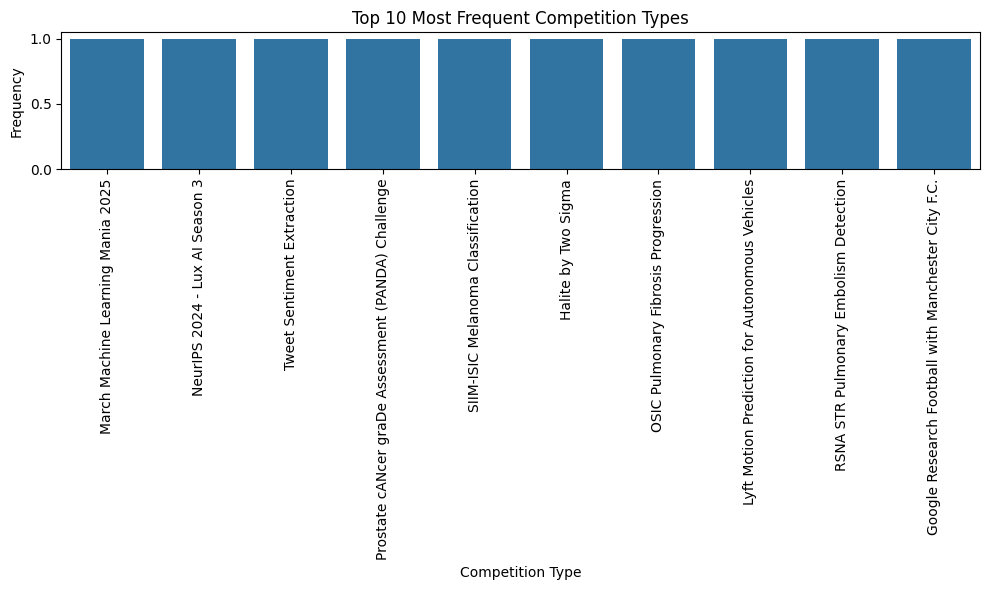

<ipython-input-5-1c447b0232be>:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


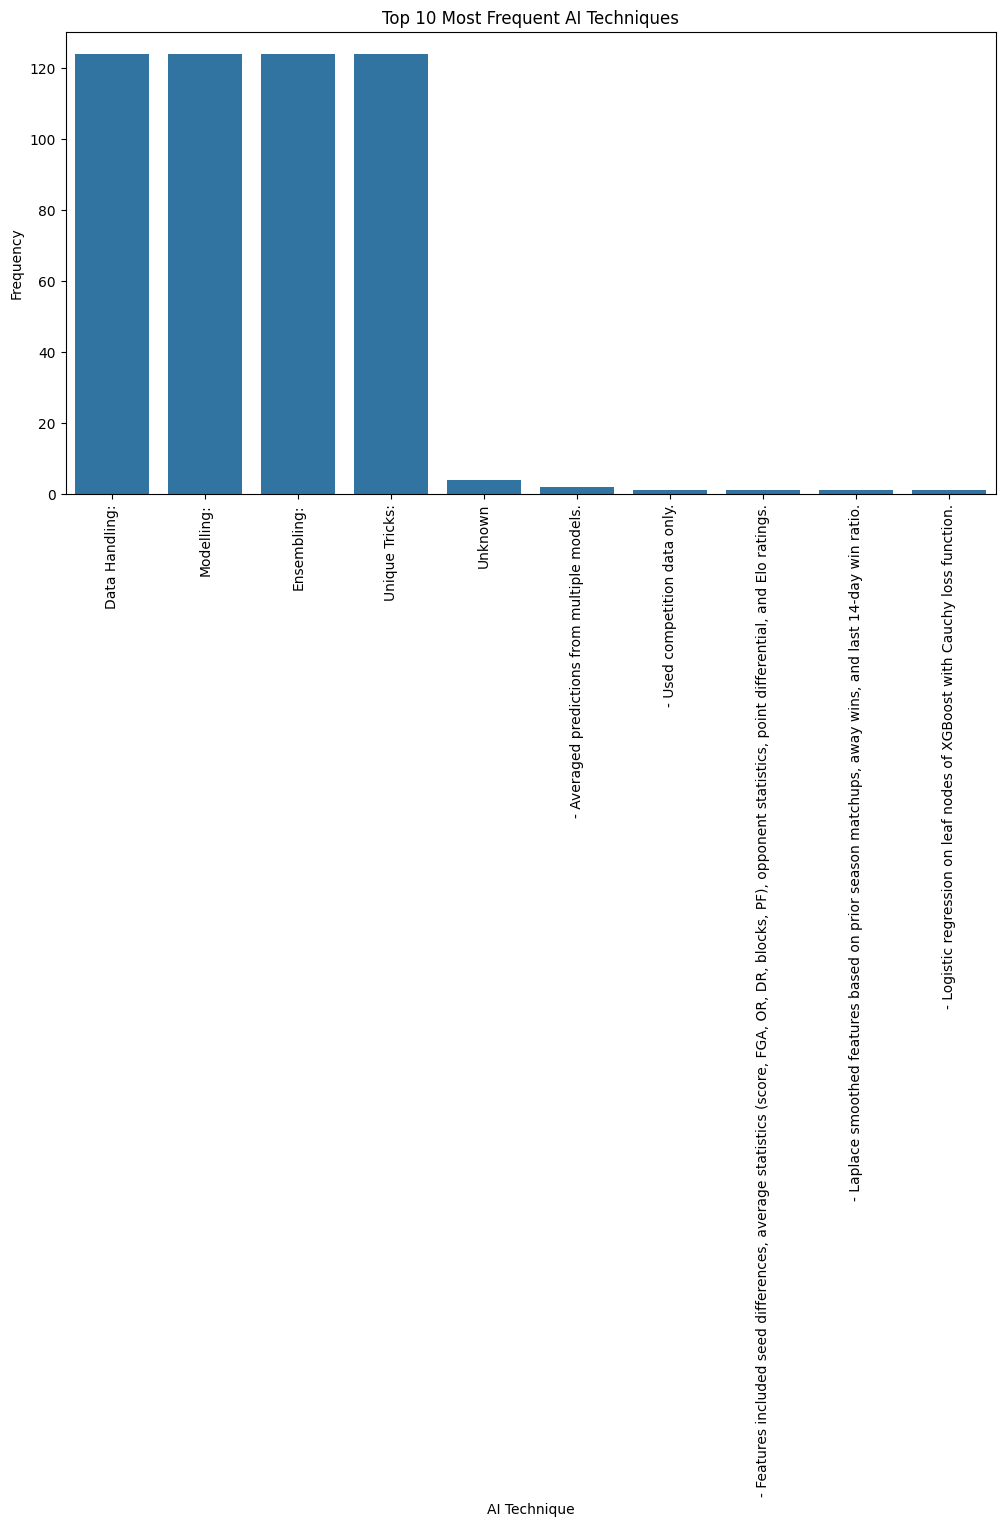

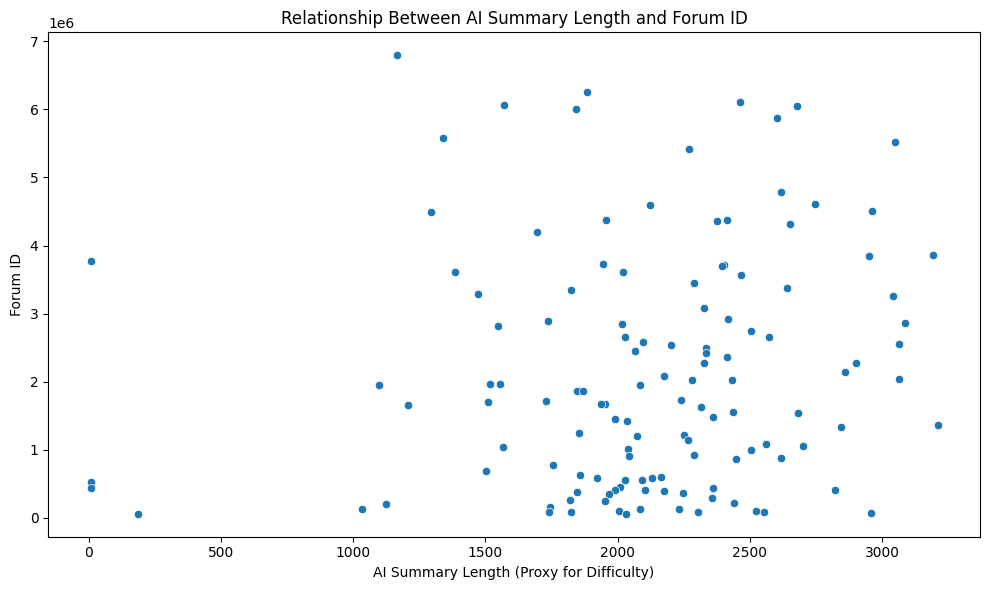

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Analyze competition types
competition_type_counts = df['Title'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=competition_type_counts.index[:10], y=competition_type_counts.values[:10])
plt.xticks(rotation=90)
plt.xlabel("Competition Type")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Competition Types")
plt.tight_layout()
plt.show()

# 2. Analyze AI techniques
from collections import defaultdict

ai_techniques = defaultdict(int)
for summary in df['AI_Summary']:
    for technique in summary.split('\n'):
        if technique.strip():
            ai_techniques[technique.strip()] += 1
sorted_techniques = dict(sorted(ai_techniques.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(sorted_techniques.keys())[:10], y=list(sorted_techniques.values())[:10])
plt.xticks(rotation=90)
plt.xlabel("AI Technique")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent AI Techniques")
plt.tight_layout()
plt.show()

# 3. Explore the relationship between competition difficulty and AI techniques
# (Placeholder for difficulty analysis - requires a clearer definition of difficulty)
# For demonstration, we'll use the length of the AI summary as a proxy for difficulty
df['AI_Summary_Length'] = df['AI_Summary'].str.len()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='AI_Summary_Length', y='ForumId', data=df)
plt.xlabel("AI Summary Length (Proxy for Difficulty)")
plt.ylabel("Forum ID")
plt.title("Relationship Between AI Summary Length and Forum ID")
plt.tight_layout()
plt.show()

## Data visualization

### Subtask:
Visualize the key findings from the data analysis.


**Reasoning**:
Visualize the key findings from the data analysis as requested in the instructions, using the provided dataframe.



<ipython-input-6-18ec9dfd3b79>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=competition_type_counts.index, y=competition_type_counts.values, palette='viridis')


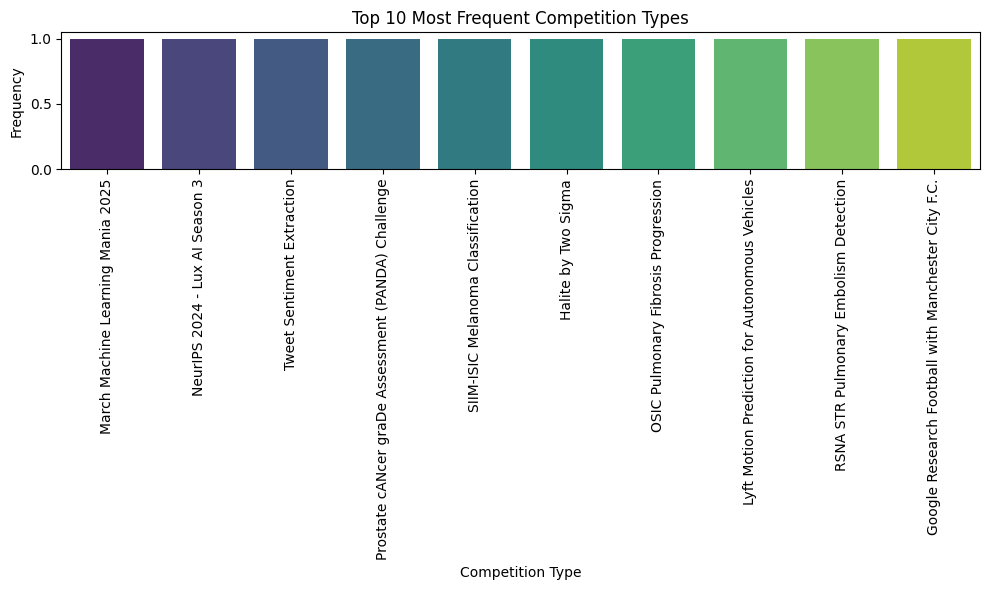

<ipython-input-6-18ec9dfd3b79>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_techniques.keys())[:10], y=list(sorted_techniques.values())[:10], palette='magma')
<ipython-input-6-18ec9dfd3b79>:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


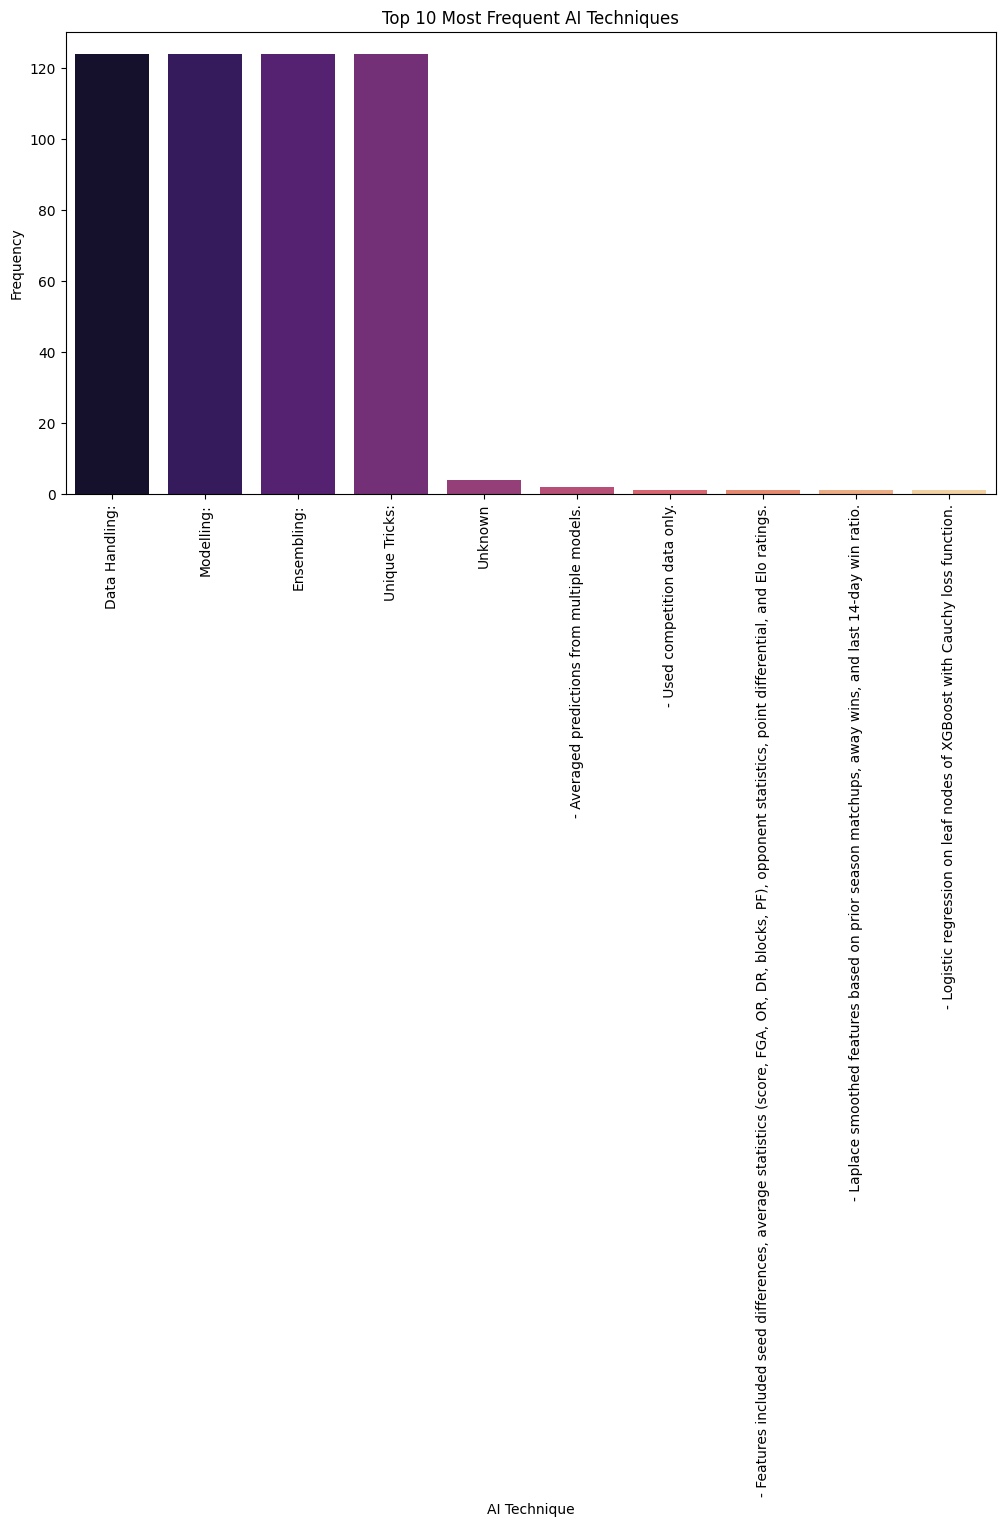

<ipython-input-6-18ec9dfd3b79>:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


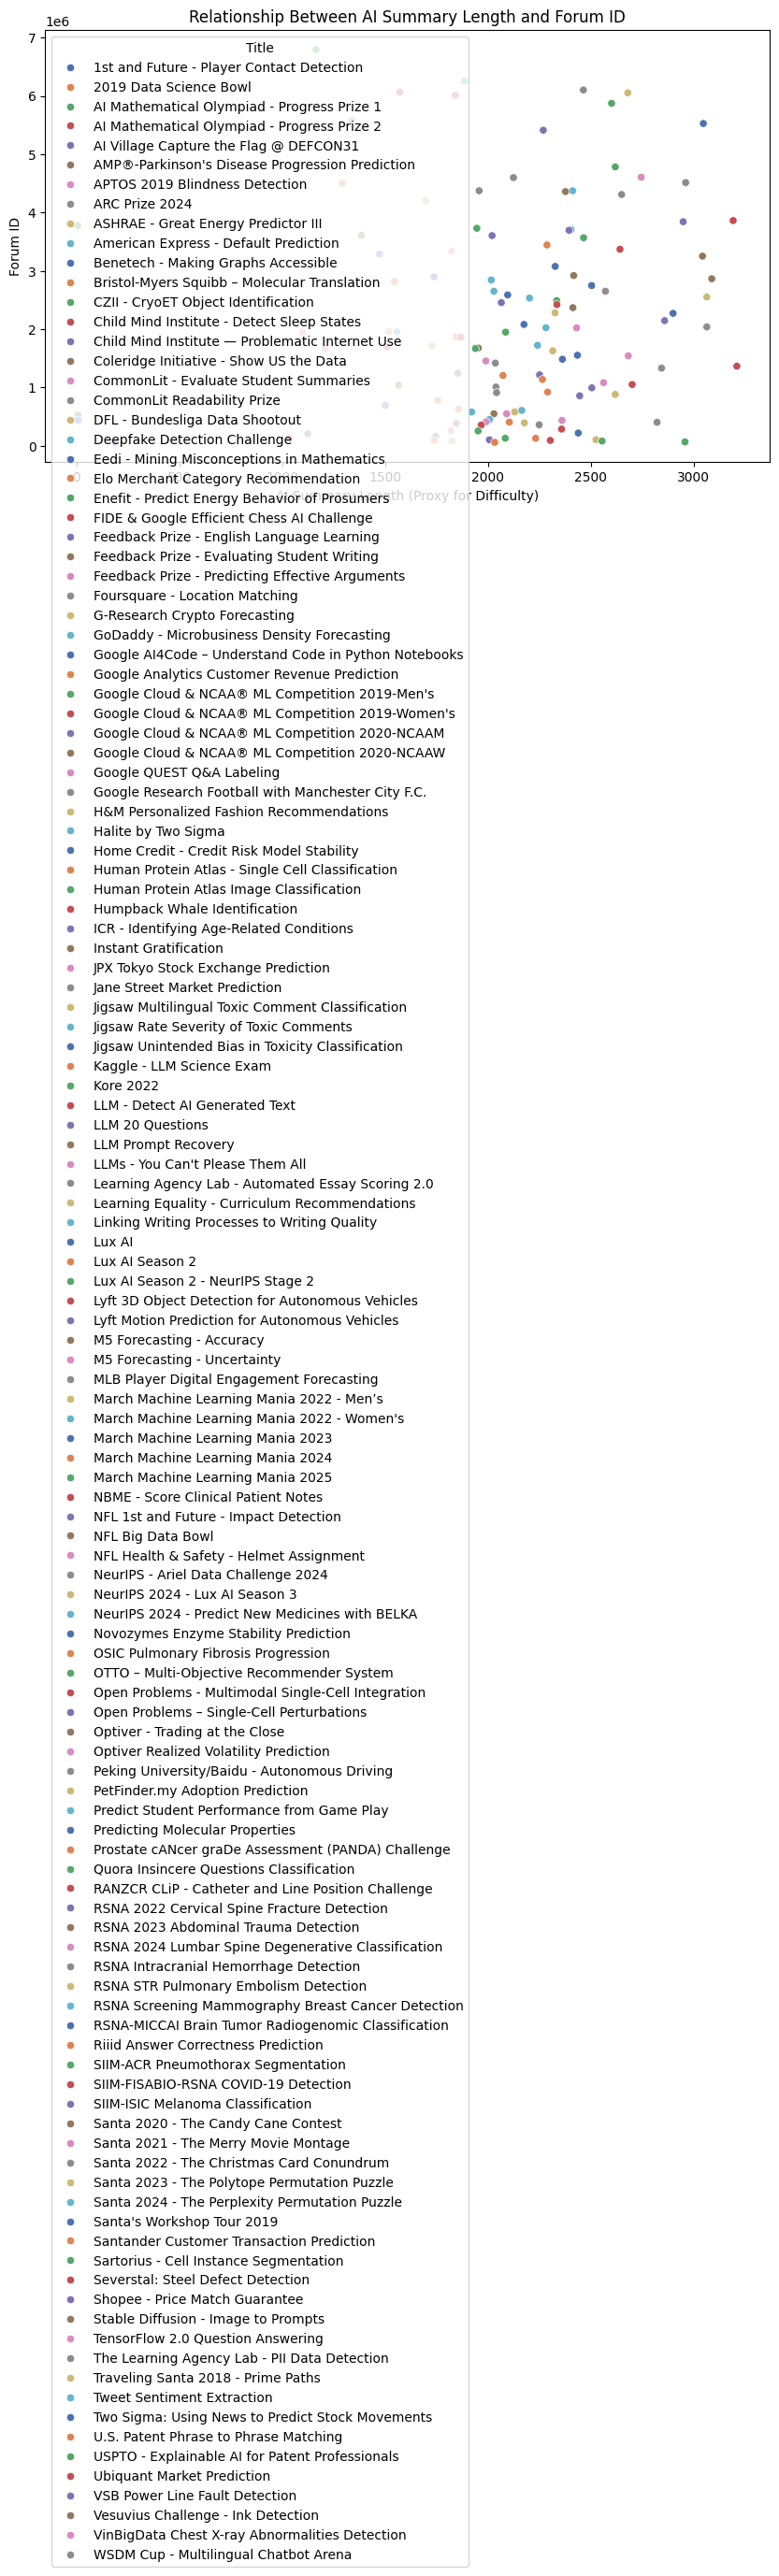

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Competition Types
plt.figure(figsize=(10, 6))
competition_type_counts = df['Title'].value_counts().nlargest(10)
sns.barplot(x=competition_type_counts.index, y=competition_type_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel("Competition Type")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Competition Types")
plt.tight_layout()
plt.show()

# AI Techniques
ai_techniques = {}
for summary in df['AI_Summary']:
    for technique in summary.split('\n'):
      technique = technique.strip()
      if technique:
        ai_techniques[technique] = ai_techniques.get(technique, 0) + 1
sorted_techniques = dict(sorted(ai_techniques.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(12, 6))
sns.barplot(x=list(sorted_techniques.keys())[:10], y=list(sorted_techniques.values())[:10], palette='magma')
plt.xticks(rotation=90)
plt.xlabel("AI Technique")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent AI Techniques")
plt.tight_layout()
plt.show()

# Competition Difficulty vs. Forum ID
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AI_Summary_Length', y='ForumId', data=df, hue=df['Title'].astype('category'), palette='deep')
plt.xlabel("AI Summary Length (Proxy for Difficulty)")
plt.ylabel("Forum ID")
plt.title("Relationship Between AI Summary Length and Forum ID")
plt.tight_layout()
plt.show()



---

